# House Price Prediction

## 2.1 Load and Inspect the Dataset

In [2]:
from pathlib import Path

print("Notebook working folder:")
print(Path.cwd())

print("\nCSV files found inside the project:")
for file in Path("..").rglob("*.csv"):
    print(file)

Notebook working folder:
c:\Users\lenovo\Documents\house-price-project\notebooks\data

CSV files found inside the project:
..\data\house_prices.csv


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = Path("house_prices.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing-value percentage:")
display(
    (df.isna().mean() * 100)
    .sort_values(ascending=False)
    .to_frame("missing_%")
)

print("\nNumeric summary only:")
display(df.describe().T)

Dataset shape: (187531, 21)

Columns:
['Index', 'Title', 'Description', 'Amount(in rupees)', 'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area', 'Dimensions', 'Plot Area']


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN



Data types:


,dtype
Index,int64
Title,str
Description,str
Amount(in rupees),str
Price (in rupees),float64
location,str
Carpet Area,str
Status,str
Floor,str
Transaction,str



Missing-value percentage:


,missing_%
Plot Area,100.000000
Dimensions,100.000000
Society,58.485264
Super Area,57.422506
Car Parking,55.114621
overlooking,43.425354
Carpet Area,43.018488
facing,37.451408
Ownership,34.936624
Balcony,26.094352



Numeric summary only:


,count,mean,std,min,25%,50%,75%,max
Index,187531.0,93765.000000,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Price (in rupees),169866.0,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
Dimensions,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Plot Area,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Shape: (187531, 21)

Columns:
['Index', 'Title', 'Description', 'Amount(in rupees)', 'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area', 'Dimensions', 'Plot Area']


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


## 2.2 Exploratory Data Analysis (EDA)

In [5]:
# Inspect the fields we will clean and model with

columns_to_inspect = [
    "Amount(in rupees)",
    "Price (in rupees)",
    "Carpet Area",
    "Super Area",
    "Floor",
    "Bathroom",
    "Balcony",
    "Car Parking",
    "location",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]

for col in columns_to_inspect:
    print(f"\n{'=' * 70}")
    print(f"{col}")
    print(f"{'=' * 70}")
    print("Missing %:", round(df[col].isna().mean() * 100, 2))
    print(df[col].value_counts(dropna=False).head(12))# Inspect the fields we will clean and model with

columns_to_inspect = [
    "Amount(in rupees)",
    "Price (in rupees)",
    "Carpet Area",
    "Super Area",
    "Floor",
    "Bathroom",
    "Balcony",
    "Car Parking",
    "location",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]

for col in columns_to_inspect:
    print(f"\n{'=' * 70}")
    print(f"{col}")
    print(f"{'=' * 70}")
    print("Missing %:", round(df[col].isna().mean() * 100, 2))
    print(df[col].value_counts(dropna=False).head(12))


Amount(in rupees)
Missing %: 0.0
Amount(in rupees)
Call for Price    9684
85 Lac            5264
65 Lac            4229
60 Lac            3869
70 Lac            3801
35 Lac            3369
75 Lac            3144
90 Lac            3143
40 Lac            3098
50 Lac            3006
1.75 Cr           2879
30 Lac            2790
Name: count, dtype: int64

Price (in rupees)
Missing %: 9.42
Price (in rupees)
NaN        17665
4000.0      2463
5000.0      2286
10000.0     2273
3200.0      1479
18000.0     1420
6522.0      1241
6000.0      1203
6667.0      1076
11056.0      953
5333.0       909
7500.0       888
Name: count, dtype: int64

Carpet Area
Missing %: 43.02
Carpet Area
NaN          80673
1000 sqft     5285
900 sqft      4649
1300 sqft     3457
1600 sqft     2752
600 sqft      2225
1500 sqft     2151
950 sqft      1940
1250 sqft     1675
850 sqft      1674
400 sqft      1657
1700 sqft     1556
Name: count, dtype: int64

Super Area
Missing %: 57.42
Super Area
NaN          107685
1100 sq

## 2.3 Data Cleaning and Feature Engineering

In [6]:
import re
import numpy as np
import pandas as pd

# Work on a copy so the original loaded dataset remains unchanged
data = df.copy()

def parse_price_rupees(value):
    """Convert values such as '85 Lac' and '1.75 Cr' into rupees."""
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower().replace(",", "")

    if "call" in text or text in {"", "nan"}:
        return np.nan

    match = re.search(r"(\d+(?:\.\d+)?)", text)
    if not match:
        return np.nan

    number = float(match.group(1))

    if "lac" in text or "lakh" in text:
        return number * 100_000
    if "cr" in text or "crore" in text:
        return number * 10_000_000

    return number


def parse_area_sqft(value):
    """Extract property area and convert square metres to square feet."""
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower().replace(",", "")
    match = re.search(r"(\d+(?:\.\d+)?)", text)

    if not match:
        return np.nan

    area = float(match.group(1))

    if "sqm" in text or "sq m" in text or "square meter" in text:
        return area * 10.764

    return area


def parse_floor_number(value):
    """Extract a numerical floor; Ground=0, Basement=-1."""
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()

    if "ground" in text:
        return 0
    if "basement" in text:
        return -1

    match = re.search(r"-?\d+", text)
    return float(match.group()) if match else np.nan


def parse_numeric(value):
    """Extract the first number from values such as '1 Open' or '2 Bathrooms'."""
    if pd.isna(value):
        return np.nan

    match = re.search(r"\d+", str(value))
    return float(match.group()) if match else np.nan


# Target
data["price_clean"] = data["Amount(in rupees)"].apply(parse_price_rupees)

# Use carpet area first; fill missing carpet areas with super area where available
data["carpet_area_sqft"] = data["Carpet Area"].apply(parse_area_sqft)
data["super_area_sqft"] = data["Super Area"].apply(parse_area_sqft)
data["area_sqft"] = data["carpet_area_sqft"].fillna(data["super_area_sqft"])

# Numeric property features
data["floor_num"] = data["Floor"].apply(parse_floor_number)
data["bathroom_num"] = data["Bathroom"].apply(parse_numeric)
data["balcony_num"] = data["Balcony"].apply(parse_numeric)
data["parking_num"] = data["Car Parking"].apply(parse_numeric)

# Basic cleanup for categorical columns
categorical_columns = [
    "location",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]

for col in categorical_columns:
    data[col] = data[col].fillna("Unknown").astype(str).str.strip()

print("Rows before removing invalid prices:", len(data))

# A supervised regression model cannot train without a target
data = data.dropna(subset=["price_clean"]).copy()

# Remove impossible values
data = data[
    (data["price_clean"] > 0) &
    (data["area_sqft"].isna() | (data["area_sqft"] > 0))
].copy()

print("Rows after removing invalid prices:", len(data))

display(
    data[
        [
            "Amount(in rupees)",
            "price_clean",
            "Carpet Area",
            "Super Area",
            "area_sqft",
            "Floor",
            "floor_num",
            "Bathroom",
            "bathroom_num",
            "Balcony",
            "balcony_num"
        ]
    ].head(10)
)

Rows before removing invalid prices: 187531
Rows after removing invalid prices: 177847


,Amount(in rupees),price_clean,Carpet Area,Super Area,area_sqft,Floor,floor_num,Bathroom,bathroom_num,Balcony,balcony_num
0,42 Lac,4200000.0,500 sqft,NaN,500.0,10 out of 11,10.0,1,1.0,2,2.0
1,98 Lac,9800000.0,473 sqft,NaN,473.0,3 out of 22,3.0,2,2.0,NaN,NaN
2,1.40 Cr,14000000.0,779 sqft,NaN,779.0,10 out of 29,10.0,2,2.0,NaN,NaN
3,25 Lac,2500000.0,530 sqft,NaN,530.0,1 out of 3,1.0,1,1.0,1,1.0
4,1.60 Cr,16000000.0,635 sqft,NaN,635.0,20 out of 42,20.0,2,2.0,NaN,NaN
5,45 Lac,4500000.0,NaN,680 sqft,680.0,2 out of 7,2.0,1,1.0,1,1.0
6,16.5 Lac,1650000.0,550 sqft,NaN,550.0,4 out of 5,4.0,1,1.0,NaN,NaN
7,60 Lac,6000000.0,NaN,575 sqft,575.0,Ground out of 7,0.0,1,1.0,NaN,NaN
8,60 Lac,6000000.0,NaN,600 sqft,600.0,Ground out of 2,0.0,1,1.0,NaN,NaN
9,1.60 Cr,16000000.0,900 sqft,NaN,900.0,3 out of 27,3.0,3,3.0,1,1.0


In [7]:
# Keep the 50 most common locations.
# All less common locations become "Other".

TOP_N_LOCATIONS = 50

top_locations = data["location"].value_counts().head(TOP_N_LOCATIONS).index

data["location_grouped"] = np.where(
    data["location"].isin(top_locations),
    data["location"],
    "Other"
)

print("Unique original locations:", data["location"].nunique())
print("Unique grouped locations:", data["location_grouped"].nunique())

print("\nMost common grouped locations:")
display(
    data["location_grouped"]
    .value_counts()
    .head(15)
    .to_frame("listing_count")
)

# Calculate price per square foot only when a valid area exists
data["price_per_sqft"] = data["price_clean"] / data["area_sqft"]

valid_ppsf = (
    data["price_per_sqft"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

lower_limit = valid_ppsf.quantile(0.01)
upper_limit = valid_ppsf.quantile(0.99)

print("\nPrice-per-square-foot limits:")
print(f"1st percentile: ₹{lower_limit:,.2f}")
print(f"99th percentile: ₹{upper_limit:,.2f}")

rows_before_outliers = len(data)

# Keep listings without known area.
# For listings with valid area, remove the lowest and highest 1% of price-per-sqft values.
data = data[
    data["price_per_sqft"].isna()
    | data["price_per_sqft"].between(lower_limit, upper_limit)
].copy()

print("\nRows before outlier removal:", rows_before_outliers)
print("Rows after outlier removal:", len(data))

# Check missing values in the features we intend to model later
model_check_columns = [
    "price_clean",
    "area_sqft",
    "floor_num",
    "bathroom_num",
    "balcony_num",
    "parking_num",
    "location_grouped",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]

print("\nMissing values in model features:")
display(
    (data[model_check_columns].isna().mean() * 100)
    .sort_values(ascending=False)
    .to_frame("missing_%")
)

Unique original locations: 81
Unique grouped locations: 51

Most common grouped locations:


,listing_count
location_grouped,
new-delhi,24945
bangalore,23262
kolkata,21605
gurgaon,18846
ahmedabad,12614
hyderabad,11147
chennai,10163
jaipur,7867
greater-noida,4490



Price-per-square-foot limits:
1st percentile: ₹2,285.21
99th percentile: ₹101,503.76

Rows before outlier removal: 177847
Rows after outlier removal: 174561

Missing values in model features:


,missing_%
parking_num,53.586425
balcony_num,26.374734
floor_num,3.958502
bathroom_num,0.425639
area_sqft,0.051558
price_clean,0.000000
location_grouped,0.000000
Furnishing,0.000000
Transaction,0.000000
Ownership,0.000000


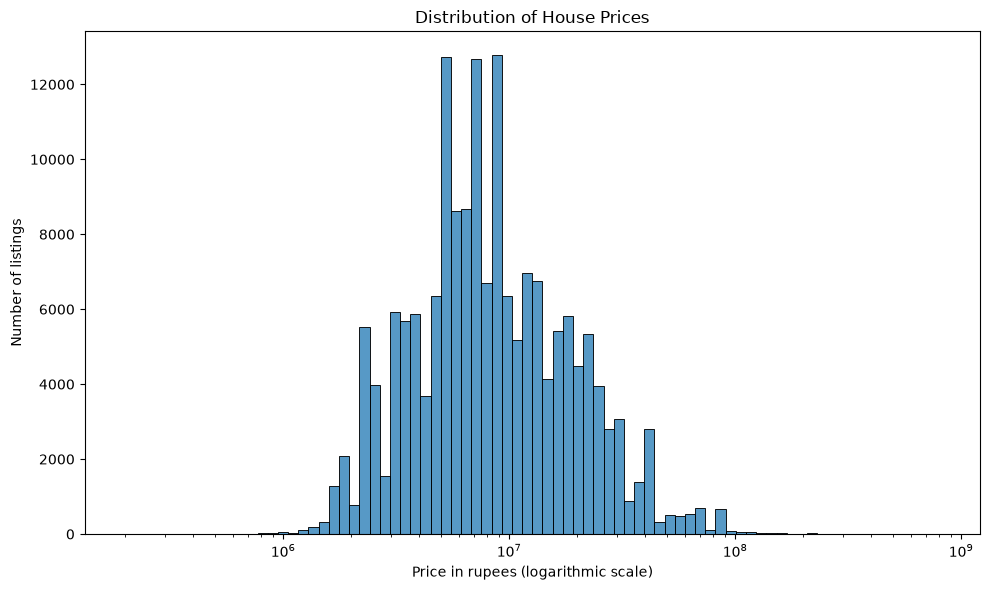

In [8]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=data,
    x="price_clean",
    bins=80,
    log_scale=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Price in rupees (logarithmic scale)")
plt.ylabel("Number of listings")
plt.tight_layout()
plt.show()

### Plot 1 — Price Distribution

The price distribution is heavily right-skewed. Most listings are concentrated in the lower and middle price ranges, while a smaller number of expensive properties creates a long upper tail. The logarithmic x-axis makes the distribution easier to visualize.

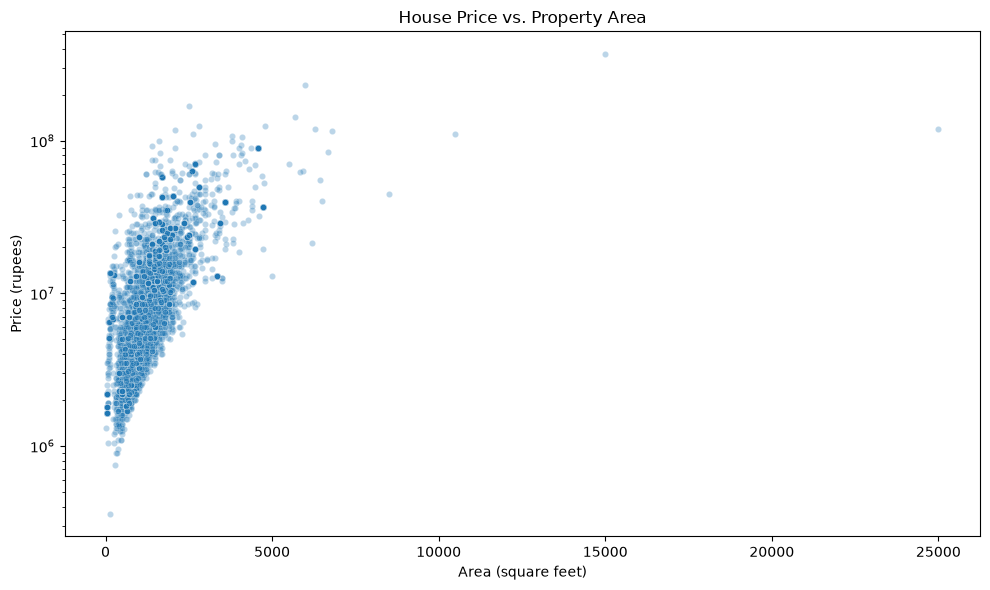

In [9]:
scatter_data = data[
    data["area_sqft"].notna()
    & (data["area_sqft"] > 0)
    & (data["price_clean"] > 0)
].copy()

scatter_sample = scatter_data.sample(
    n=min(10_000, len(scatter_data)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=scatter_sample,
    x="area_sqft",
    y="price_clean",
    alpha=0.30,
    s=20
)

plt.title("House Price vs. Property Area")
plt.xlabel("Area (square feet)")
plt.ylabel("Price (rupees)")
plt.yscale("log")
plt.tight_layout()
plt.show()

### Plot 2 — Price versus Property Area

Price generally increases as property area increases. However, the wide spread of prices for similar-sized properties shows that area alone does not determine price. Location, furnishing, floor, and other property characteristics also contribute.

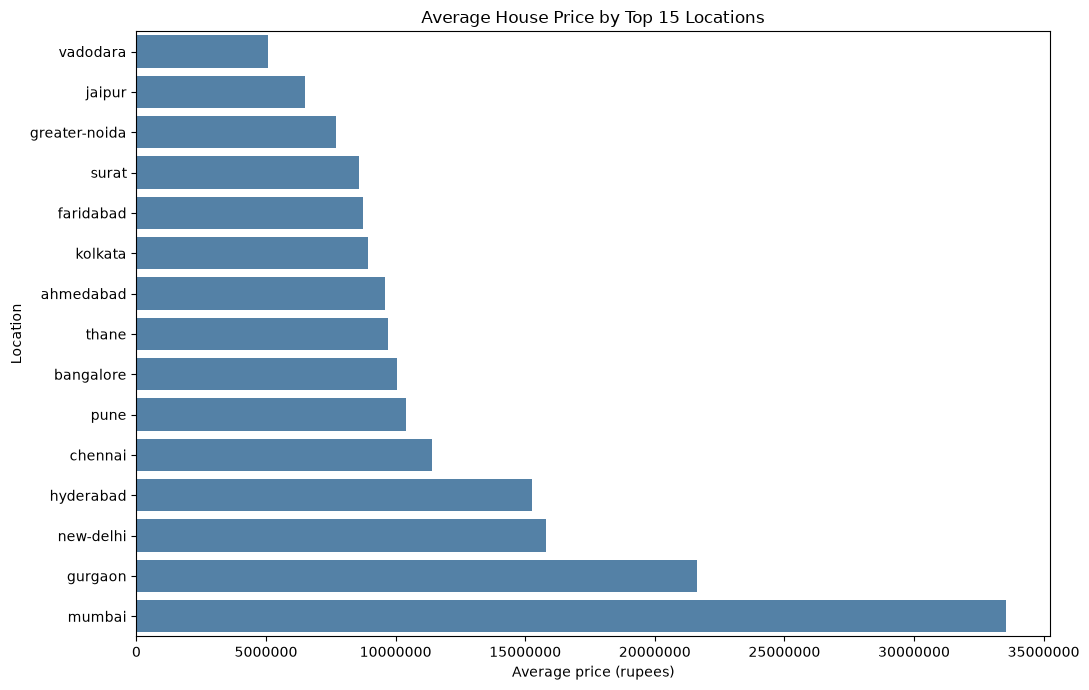

In [10]:
top_15_locations = data["location"].value_counts().head(15).index

location_price_summary = (
    data[data["location"].isin(top_15_locations)]
    .groupby("location", as_index=False)["price_clean"]
    .mean()
    .sort_values("price_clean", ascending=True)
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=location_price_summary,
    x="price_clean",
    y="location",
    color="steelblue"
)

plt.title("Average House Price by Top 15 Locations")
plt.xlabel("Average price (rupees)")
plt.ylabel("Location")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

### Plot 3 — Average Price by Location

Average house prices differ substantially across the most frequent locations. Mumbai has the highest average price among the displayed locations, while Vadodara has the lowest. This confirms that location is an important predictive feature. Grouping less frequent locations into `Other` also reduces the dimensionality caused by high-cardinality location values.

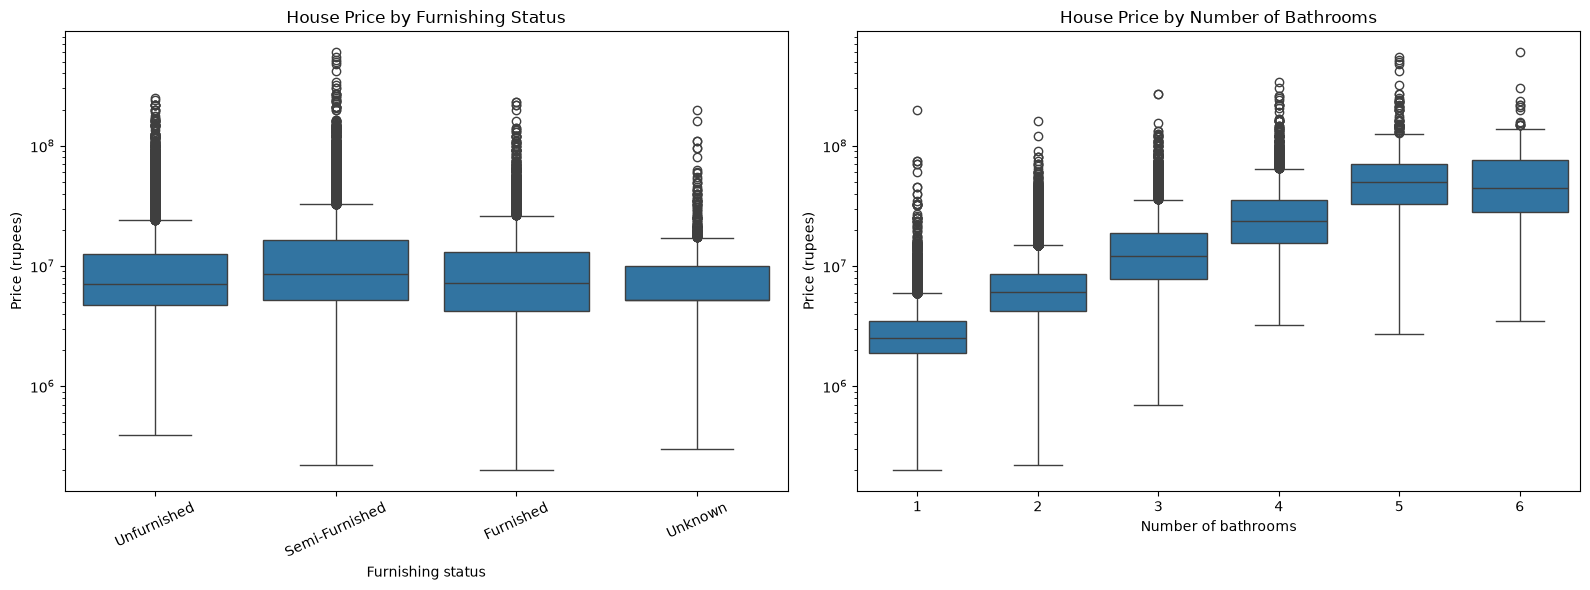

In [11]:
box_data = data.copy()

# Keep the most common furnishing categories
top_furnishing = box_data["Furnishing"].value_counts().head(5).index
box_data = box_data[
    box_data["Furnishing"].isin(top_furnishing)
].copy()

# Fill missing bathroom values only for visualization
box_data["bathroom_group"] = (
    box_data["bathroom_num"]
    .fillna(box_data["bathroom_num"].median())
    .round()
    .astype(int)
)

# Keep the six most common bathroom counts
common_bathrooms = (
    box_data["bathroom_group"]
    .value_counts()
    .head(6)
    .index
)

box_data = box_data[
    box_data["bathroom_group"].isin(common_bathrooms)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=box_data,
    x="Furnishing",
    y="price_clean",
    ax=axes[0]
)

axes[0].set_title("House Price by Furnishing Status")
axes[0].set_xlabel("Furnishing status")
axes[0].set_ylabel("Price (rupees)")
axes[0].tick_params(axis="x", rotation=25)
axes[0].set_yscale("log")

sns.boxplot(
    data=box_data,
    x="bathroom_group",
    y="price_clean",
    ax=axes[1]
)

axes[1].set_title("House Price by Number of Bathrooms")
axes[1].set_xlabel("Number of bathrooms")
axes[1].set_ylabel("Price (rupees)")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

### Plot 4 — Price by Furnishing Status and Bathrooms

Furnishing status and bathroom count are both associated with different price distributions. The median price generally increases as the number of bathrooms increases. Furnishing categories overlap considerably, which suggests that furnishing alone is not sufficient to explain price differences. Location, area, and other property characteristics also influence house prices.

## 2.4 Build a Pipeline and Train Models

In [24]:
top_locations = data["location"].value_counts().head(50).index

data["location_grouped"] = data["location"].where(
    data["location"].isin(top_locations),
    "Other",
)

print(data["location_grouped"].nunique())

51


In [25]:
# Define the features used by the models

numeric_features = [
    "area_sqft",
    "floor_num",
    "bathroom_num",
    "balcony_num"
]

categorical_features = [
    "location_grouped",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]

model_features = numeric_features + categorical_features

X = data[model_features].copy()
y = data["price_clean"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Feature matrix shape: (174561, 9)
Target shape: (174561,)


,area_sqft,floor_num,bathroom_num,balcony_num,location_grouped,Furnishing,Transaction,Ownership,facing
0,500.0,10.0,1.0,2.0,thane,Unfurnished,Resale,Unknown,Unknown
1,473.0,3.0,2.0,NaN,thane,Semi-Furnished,Resale,Freehold,East
2,779.0,10.0,2.0,NaN,thane,Unfurnished,Resale,Freehold,East
3,530.0,1.0,1.0,1.0,thane,Unfurnished,Resale,Unknown,Unknown
4,635.0,20.0,2.0,NaN,thane,Unfurnished,Resale,Co-operative Society,West


0     4200000.0
1     9800000.0
2    14000000.0
3     2500000.0
4    16000000.0
Name: price_clean, dtype: float64

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Split the data before fitting any preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 139648
Testing rows: 34913


In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Models created successfully.")

Models created successfully.


In [28]:
print("Training Linear Regression...")
linear_model.fit(X_train, y_train)
print("Linear Regression complete.")

print("\nTraining Random Forest...")
random_forest_model.fit(X_train, y_train)
print("Random Forest complete.")

Training Linear Regression...
Linear Regression complete.

Training Random Forest...
Random Forest complete.


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict on the unseen test set
linear_predictions = linear_model.predict(X_test)
rf_predictions = random_forest_model.predict(X_test)

def evaluate_model(name, y_true, predictions):
    mae = mean_absolute_error(y_true, predictions)
    rmse = mean_squared_error(y_true, predictions) ** 0.5
    r2 = r2_score(y_true, predictions)

    return {
        "Model": name,
        "MAE (₹)": mae,
        "RMSE (₹)": rmse,
        "R²": r2
    }

results = pd.DataFrame([
    evaluate_model("Linear Regression", y_test, linear_predictions),
    evaluate_model("Random Forest", y_test, rf_predictions)
])

results_display = results.copy()
results_display["MAE (₹)"] = results_display["MAE (₹)"].map(lambda x: f"₹{x:,.2f}")
results_display["RMSE (₹)"] = results_display["RMSE (₹)"].map(lambda x: f"₹{x:,.2f}")
results_display["R²"] = results_display["R²"].map(lambda x: f"{x:.4f}")

display(results_display)

,Model,MAE (₹),RMSE (₹),R²
0,Linear Regression,"₹4,580,502.41","₹9,317,660.52",0.5988
1,Random Forest,"₹1,051,386.87","₹5,928,642.03",0.8376


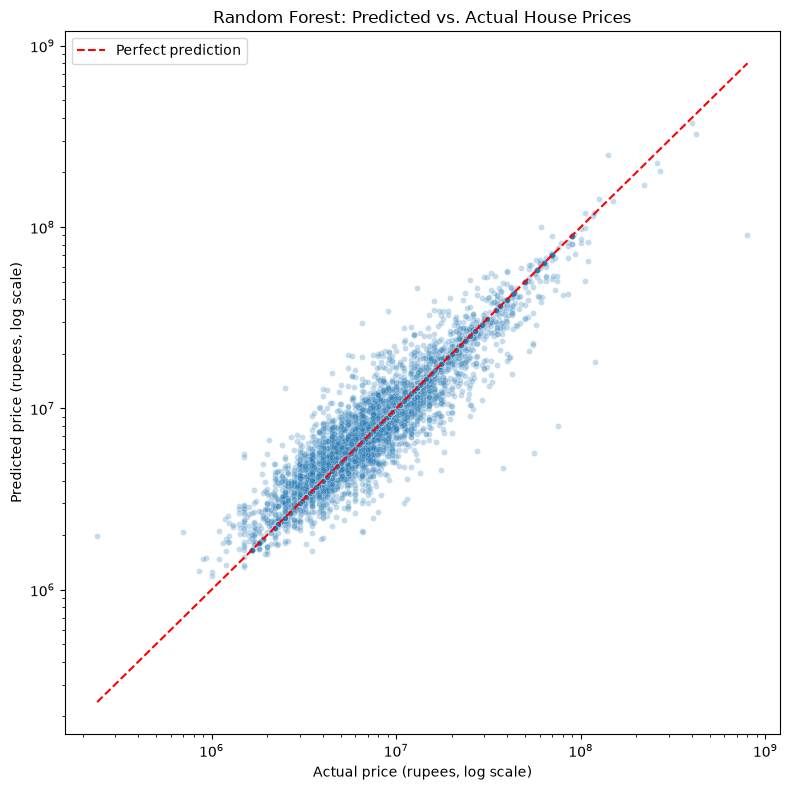

In [30]:
# Use the Random Forest predictions for the visual comparison
comparison_data = pd.DataFrame({
    "Actual price": y_test,
    "Predicted price": rf_predictions
})

comparison_sample = comparison_data.sample(
    n=min(10_000, len(comparison_data)),
    random_state=42
)

plt.figure(figsize=(8, 8))

sns.scatterplot(
    data=comparison_sample,
    x="Actual price",
    y="Predicted price",
    alpha=0.25,
    s=18
)

min_price = min(comparison_sample["Actual price"].min(), comparison_sample["Predicted price"].min())
max_price = max(comparison_sample["Actual price"].max(), comparison_sample["Predicted price"].max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--",
    color="red",
    label="Perfect prediction"
)

plt.xscale("log")
plt.yscale("log")
plt.title("Random Forest: Predicted vs. Actual House Prices")
plt.xlabel("Actual price (rupees, log scale)")
plt.ylabel("Predicted price (rupees, log scale)")
plt.legend()
plt.tight_layout()
plt.show()

## 2.6 Export the Model and Locations

In [31]:
import json
import joblib
from pathlib import Path

# Your notebook kernel runs from: house-price-project/notebooks/data
# This points to: house-price-project/backend/models
output_dir = Path("..") / ".." / "backend" / "models"
output_dir.mkdir(parents=True, exist_ok=True)

# Save the complete Random Forest pipeline:
# preprocessing + one-hot encoder + imputation + regressor
model_path = output_dir / "house_price.pkl"
joblib.dump(random_forest_model, model_path)

# Save locations for the React dropdown
locations_path = output_dir / "locations.json"

allowed_locations = sorted(
    data["location_grouped"]
    .dropna()
    .unique()
    .tolist()
)

with open(locations_path, "w", encoding="utf-8") as file:
    json.dump(allowed_locations, file, ensure_ascii=False, indent=2)

print("Model saved to:", model_path.resolve())
print("Locations saved to:", locations_path.resolve())
print("Number of allowed locations:", len(allowed_locations))

Model saved to: C:\Users\lenovo\Documents\house-price-project\backend\models\house_price.pkl
Locations saved to: C:\Users\lenovo\Documents\house-price-project\backend\models\locations.json
Number of allowed locations: 51


In [32]:
# Reload the saved model and test it with one unseen test row

loaded_model = joblib.load(model_path)

sample = X_test.iloc[[0]]
sample_prediction = loaded_model.predict(sample)[0]

print("Reloaded prediction:", f"₹{sample_prediction:,.2f}")
print("Actual price:", f"₹{y_test.iloc[0]:,.2f}")

with open(locations_path, "r", encoding="utf-8") as file:
    loaded_locations = json.load(file)

print("Reloaded locations:", len(loaded_locations))

Reloaded prediction: ₹8,500,000.00
Actual price: ₹8,500,000.00
Reloaded locations: 51


In [33]:
import json

locations = sorted(
    data["location_grouped"]
    .dropna()
    .unique()
    .tolist()
)

with open("locations.json", "w", encoding="utf-8") as file:
    json.dump(locations, file, ensure_ascii=False, indent=2)

print(f"Exported {len(locations)} locations.")

Exported 51 locations.


In [34]:
import joblib

joblib.dump(random_forest_model, "house_price.pkl")
print("Random Forest model exported as house_price.pkl")

Random Forest model exported as house_price.pkl
